# Notebook 03_0 — Systematic Domain Phrase Extraction for Phrase-Aware LIME

**Goal:** build an auditable list of consent-relevant multi-word phrases from the actual decision-making corpus, so Notebook 03 can use phrase-aware LIME without manually inventing phrases.

## tldr

This produces:

- `data/domain_phrase_map.csv` — compact phrase map for phrase-aware LIME.
- `outputs/domain_phrase_candidates.csv` — full scored candidate table.
- `outputs/domain_phrase_audit.csv` — top phrases with source snippets for human checking.
- `outputs/domain_phrase_summary.png` — evidence-score plot for the strongest extracted phrases.

The method is intentionally conservative: phrases are extracted from the corpus, ranked by class-specific evidence, and preserved with audit fields so they can be reviewed before report writing.


## Context & Methods

Phrase-level explanations are needed because consent meanings often live in short expressions rather than individual words. Examples include `no choice`, `not explained`, `without consent`, and `well informed`.

This notebook uses a systematic phrase extraction pipeline:

1. Extract 2- to 4-word candidate phrases from the 278 decision-making responses.
2. Preserve negations and short function words during extraction, because they are often semantically important in consent language.
3. Rank phrases by class-specific evidence using:
   - **class-based TF-IDF**, following the logic of BERTopic's c-TF-IDF topic representation;
   - **log-odds against the rest of the corpus**, a standard discriminative keyword approach;
   - **definition overlap**, comparing each phrase to the five consent-code definitions.
4. Save candidate phrases with source snippets for a audit.
5. Export a compact phrase map for next process.

### Method references (added on as per reqmnt)

- Grootendorst (2022), BERTopic, supports class-based TF-IDF as a way to represent what distinguishes a class/topic.
- Mihalcea and Tarau (2004), TextRank, supports graph/ranking approaches to automatic keyword and keyphrase extraction.
- Rose et al. (2010), RAKE, supports extracting multi-word keyphrases from individual documents.
- Campos et al. (2020), YAKE, supports unsupervised keyphrase extraction from local textual features.

### Key assumptions

- The working classification task uses the resolved `Final codes`/`label` field as a single reference label per response.
- The phrase list is a **candidate interpretability aid**, not a new ground truth.
- Final thesis examples should be checked against original response snippets.
- This notebook avoids scikit-learn so it can run in the current local environment where `sklearn` imports trigger a `pyarrow` DLL issue.

In [24]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import math
import pickle
import pathlib
import re
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 140)

DATA_DIR = pathlib.Path('data')
OUTPUT_DIR = pathlib.Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

with open(DATA_DIR / 'config.pkl', 'rb') as f:
    cfg = pickle.load(f)

DECISION_CODES = cfg['DECISION_CODES']
CODE_DEFINITIONS = cfg['CODE_DEFINITIONS']
CODE_NAMES = list(DECISION_CODES.keys())
SEED = cfg.get('SEED', 42)

RANDOM_STATE = np.random.default_rng(SEED)

print('Codes:', CODE_NAMES)

Codes: ['voluntary_informed', 'feeling_pressured', 'insufficient_info', 'too_much_info', 'no_consent']


## Data

In [25]:
dm_df = pd.read_csv(DATA_DIR / 'decision_making.csv')
required_cols = {'response_text', 'label'}
missing = required_cols - set(dm_df.columns)
if missing:
    raise ValueError(f'Missing required columns: {missing}')

if 'response_id' not in dm_df.columns:
    dm_df.insert(0, 'response_id', [f'decision_making_{i:04d}' for i in range(len(dm_df))])
if 'source_row_id' not in dm_df.columns:
    dm_df.insert(1, 'source_row_id', dm_df['response_id'])

label_to_code = {v: k for k, v in DECISION_CODES.items()}
dm_df['code_name'] = dm_df['label'].map(label_to_code)

display(dm_df[['response_id', 'label', 'code_name', 'response_text']].head())
print(f'Decision-making responses: {len(dm_df)}')
print('Class counts:')
print(dm_df['code_name'].value_counts().reindex(CODE_NAMES).to_string())


,response_id,label,code_name,response_text
0,decision_making_0000,0,voluntary_informed,They wanted to induce me at 41+3. I asked to wait until 41+5
1,decision_making_0001,0,voluntary_informed,I knew a lot about inductions. I declined at 40+7 and waiting untill 41+6. I declined the gel and agreed to the hormonal pessary and it ...
2,decision_making_0002,0,voluntary_informed,"While I wanted to avoid it, I needed it in this scenario and am really glad I had the opportunity to attempt a vbac"
3,decision_making_0003,0,voluntary_informed,I was happy that an induction was medically necessary. I felt educated and empowered enough that I wouldn't have agreed to it if I didn'...
4,decision_making_0004,0,voluntary_informed,"I just want to say in this pregnancy induction was never pushed on me, I asked about it as I had one with my pervious baby."


Decision-making responses: 278
Class counts:
code_name
voluntary_informed     36
feeling_pressured      80
insufficient_info     145
too_much_info           9
no_consent              8


## Candidate Phrase Extraction

The extractor uses 2- to 4-word n-grams. It is aimed to **not** remove stopwords before candidate generation, because phrases such as `no choice`, `not asked`, `I agreed`, and `was pressured` need those words to preserve some kind of meaning.

Filtering only happens after extraction:

- remove phrases made only of stopwords;
- require at least one meaningful content/negation/consent word;
- remove phrases that are mostly punctuation, numbers, or very short fragments;
- remove weak phrase-boundary fragments such as article/preposition starts (`an induction`, `of induction`) and stopword endings (`pressured to`);
- avoid phrases whose only substantive word is generic context such as `induction` or `weeks`;
- keep phrases appearing in at least two responses by default.


In [26]:
MIN_DOC_FREQ = 2
NGRAM_RANGE = (2, 4)
TOP_N_PER_CLASS_FOR_MAP = 12
TOP_N_PER_CLASS_FOR_AUDIT = 20

# Compact stopword set: enough for phrase filtering without relying on sklearn.
BASE_STOPWORDS = {
    'a','an','the','and','or','but','if','then','than','because','as','of','at','by','for','with','about','against','between','into',
    'through','during','before','after','above','below','to','from','up','down','in','out','on','off','over','under','again','further',
    'once','here','there','when','where','why','how','all','any','both','each','few','more','most','other','some','such','only','own',
    'same','so','too','very','can','will','just','don','should','now','i','me','my','myself','we','our','ours','ourselves','you','your',
    'yours','yourself','yourselves','he','him','his','himself','she','her','hers','herself','it','its','itself','they','them','their',
    'theirs','themselves','what','which','who','whom','this','that','these','those','am','is','are','was','were','be','been','being',
    'have','has','had','having','do','does','did','doing','would','could','ought','im','ive','id','ill','youre','youve','youd','youll',
    'hes','shes','its','were','weve','wed','well','theyre','theyve','theyd','theyll'
}
NEGATION_WORDS = {'no', 'not', 'never', 'without', 'nor', 'cannot', "can't", "didn't", "wasn't", "weren't", "wouldn't", "couldn't"}
STOPWORDS_FOR_FILTERING = BASE_STOPWORDS - NEGATION_WORDS

TOKEN_PATTERN = re.compile(r"[a-zA-Z][a-zA-Z']+")

def canonical_text(text: str) -> str:
    text = str(text).lower()
    replacements = {
        "didn’t": "didn't", "wasn’t": "wasn't", "weren’t": "weren't",
        "couldn’t": "couldn't", "wouldn’t": "wouldn't", "shouldn’t": "shouldn't",
        "don’t": "don't", "can't": "can't", "cant": "can't", "cannot": "cannot",
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    text = re.sub(r"[^a-z0-9'\s]+", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def tokenize(text: str):
    return TOKEN_PATTERN.findall(canonical_text(text))


def canonical_phrase(phrase: str) -> str:
    return ' '.join(tokenize(phrase))


def generate_ngrams(tokens, ngram_range=NGRAM_RANGE):
    lo, hi = ngram_range
    for n in range(lo, hi + 1):
        if len(tokens) < n:
            continue
        for i in range(len(tokens) - n + 1):
            yield ' '.join(tokens[i:i+n])


def phrase_tokens(phrase: str):
    return tokenize(phrase)


HARD_START_STOPWORDS = {
    'a', 'an', 'the', 'of', 'to', 'at', 'by', 'in', 'on', 'for', 'with', 'from',
    'into', 'and', 'or', 'but', 'as', 'than', 'then'
}
AUX_START_WORDS = {'was', 'were', 'is', 'are', 'be', 'been', 'being', 'felt'}
PRONOUN_START_WORDS = {'i', 'we', 'they', 'she', 'he'}
GENERIC_CONTEXT_TERMS = {'induction', 'induced', 'labour', 'labor', 'hospital', 'weeks', 'birth'}


def is_candidate_phrase(phrase: str) -> bool:
    toks = phrase_tokens(phrase)
    if len(toks) < 2 or len(toks) > 4:
        return False
    if all(t in STOPWORDS_FOR_FILTERING for t in toks):
        return False

    first, last = toks[0], toks[-1]
    if first in HARD_START_STOPWORDS:
        return False
    if last in STOPWORDS_FOR_FILTERING and last not in NEGATION_WORDS:
        return False

    content_tokens = [t for t in toks if t not in STOPWORDS_FOR_FILTERING or t in NEGATION_WORDS]
    if not content_tokens:
        return False

    # Avoid phrases whose only substantive content is generic context, e.g. 'an induction'.
    strong_content = [t for t in content_tokens if t not in GENERIC_CONTEXT_TERMS]
    if not strong_content:
        return False

    # Allow phrases beginning with pronouns/auxiliaries only when they carry a strong content term.
    if first in PRONOUN_START_WORDS | AUX_START_WORDS and not strong_content:
        return False

    return True

# Count phrase occurrences and document frequencies.
total_term_freq = Counter()
total_doc_freq = Counter()
class_term_freq = {code: Counter() for code in CODE_NAMES}
class_doc_freq = {code: Counter() for code in CODE_NAMES}
class_total_terms = {code: 0 for code in CODE_NAMES}
doc_phrase_sets = []

tokenized_docs = [tokenize(text) for text in dm_df['response_text']]

for tokens, code_name in zip(tokenized_docs, dm_df['code_name']):
    phrases_in_doc = [p for p in generate_ngrams(tokens) if is_candidate_phrase(p)]
    phrase_counts = Counter(phrases_in_doc)
    phrase_set = set(phrase_counts)
    doc_phrase_sets.append(phrase_set)

    total_term_freq.update(phrase_counts)
    total_doc_freq.update(phrase_set)
    class_term_freq[code_name].update(phrase_counts)
    class_doc_freq[code_name].update(phrase_set)
    class_total_terms[code_name] += sum(phrase_counts.values())

candidate_phrases = sorted([p for p, df in total_doc_freq.items() if df >= MIN_DOC_FREQ])
print(f'Candidate phrases after filtering: {len(candidate_phrases):,}')
print(f'N-gram range: {NGRAM_RANGE}; minimum document frequency: {MIN_DOC_FREQ}')


Candidate phrases after filtering: 625
N-gram range: (2, 4); minimum document frequency: 2


## Class-Specific Ranking

In [27]:
def binary_definition_similarity(phrase, definition):
    phrase_set = set(phrase_tokens(phrase)) - STOPWORDS_FOR_FILTERING
    definition_set = set(tokenize(definition)) - STOPWORDS_FOR_FILTERING
    if not phrase_set or not definition_set:
        return 0.0
    return len(phrase_set & definition_set) / math.sqrt(len(phrase_set) * len(definition_set))

avg_class_len = np.mean([max(class_total_terms[c], 1) for c in CODE_NAMES])
total_all_terms = sum(class_total_terms.values())
alpha = 0.5
rows = []

for code_name in CODE_NAMES:
    in_total = max(class_total_terms[code_name], 1)
    out_total = max(total_all_terms - in_total, 1)
    definition = CODE_DEFINITIONS[code_name]

    for phrase in candidate_phrases:
        in_count = class_term_freq[code_name][phrase]
        if in_count == 0:
            continue
        out_count = total_term_freq[phrase] - in_count

        ctfidf = (in_count / in_total) * math.log1p(avg_class_len / max(total_term_freq[phrase], 1))
        log_odds = math.log((in_count + alpha) / (in_total - in_count + alpha)) - math.log((out_count + alpha) / (out_total - out_count + alpha))
        def_sim = binary_definition_similarity(phrase, definition)

        rows.append({
            'phrase': phrase,
            'code_name': code_name,
            'phrase_len': len(phrase_tokens(phrase)),
            'total_doc_freq': int(total_doc_freq[phrase]),
            'total_term_freq': int(total_term_freq[phrase]),
            'class_doc_freq': int(class_doc_freq[code_name][phrase]),
            'class_term_freq': int(in_count),
            'ctfidf': float(ctfidf),
            'log_odds_vs_rest': float(log_odds),
            'definition_similarity': float(def_sim),
        })

candidate_scores = pd.DataFrame(rows)

def minmax(series):
    s = series.astype(float)
    if s.max() == s.min():
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.min()) / (s.max() - s.min())

candidate_scores['ctfidf_norm'] = candidate_scores.groupby('code_name')['ctfidf'].transform(minmax)
candidate_scores['log_odds_norm'] = candidate_scores.groupby('code_name')['log_odds_vs_rest'].transform(minmax)
candidate_scores['definition_similarity_norm'] = candidate_scores.groupby('code_name')['definition_similarity'].transform(minmax)
candidate_scores['freq_norm'] = candidate_scores.groupby('code_name')['class_doc_freq'].transform(minmax)

candidate_scores['evidence_score'] = (
    0.40 * candidate_scores['ctfidf_norm'] +
    0.30 * candidate_scores['log_odds_norm'] +
    0.20 * candidate_scores['definition_similarity_norm'] +
    0.10 * candidate_scores['freq_norm']
)

candidate_scores = candidate_scores.sort_values(['code_name', 'evidence_score'], ascending=[True, False])
display(candidate_scores.head(20))
print(f'Scored class-phrase rows: {len(candidate_scores):,}')

,phrase,code_name,phrase_len,total_doc_freq,total_term_freq,class_doc_freq,class_term_freq,ctfidf,log_odds_vs_rest,definition_similarity,ctfidf_norm,log_odds_norm,definition_similarity_norm,freq_norm,evidence_score
230,felt like,feeling_pressured,2,11,13,8,10,0.010934,1.734661,0.213201,1.000000,0.735159,0.500000,1.000000,0.820548
232,felt pressured,feeling_pressured,2,6,7,5,6,0.007311,2.101788,0.426401,0.630544,0.823734,1.000000,0.571429,0.756481
292,it felt,feeling_pressured,2,6,7,5,6,0.007311,2.101788,0.301511,0.630544,0.823734,0.707107,0.571429,0.697902
207,didn't want,feeling_pressured,2,7,10,5,8,0.009171,1.859525,0.000000,0.820227,0.765285,0.000000,0.571429,0.614819
293,it felt like,feeling_pressured,3,3,4,3,4,0.005327,2.832378,0.213201,0.428236,1.000000,0.500000,0.285714,0.599866
462,want an induction,feeling_pressured,3,3,3,3,3,0.004170,2.580860,0.213201,0.310262,0.939318,0.500000,0.285714,0.534472
450,too much,feeling_pressured,2,4,4,4,4,0.005327,2.832378,0.000000,0.428236,1.000000,0.000000,0.428571,0.514152
410,say no,feeling_pressured,2,3,4,3,4,0.005327,2.832378,0.000000,0.428236,1.000000,0.000000,0.285714,0.499866
219,due date,feeling_pressured,2,11,13,6,7,0.007654,0.778218,0.000000,0.665520,0.504403,0.000000,0.714286,0.488958
171,are pressured,feeling_pressured,2,2,2,2,2,0.002944,2.244185,0.301511,0.185279,0.858090,0.707107,0.142857,0.487246


Scored class-phrase rows: 1,109


## Add Source Snippets for Audit

In [28]:
def snippet_for_phrase(phrase, code_name, max_chars=220):
    phrase_lower = phrase.lower()
    subset = dm_df[dm_df['code_name'] == code_name]
    for _, row in subset.iterrows():
        text = str(row['response_text'])
        normalised = canonical_text(text)
        pos_norm = normalised.find(phrase_lower)
        if pos_norm >= 0:
            raw_lower = text.lower()
            raw_pos = raw_lower.find(phrase_lower)
            pos = raw_pos if raw_pos >= 0 else 0
            start = max(pos - 70, 0)
            end = min(pos + len(phrase) + 120, len(text))
            snippet = text[start:end].replace('\n', ' ')
            return ('...' if start > 0 else '') + snippet + ('...' if end < len(text) else '')
    return ''

top_for_audit = (
    candidate_scores
    .groupby('code_name', group_keys=False)
    .head(TOP_N_PER_CLASS_FOR_AUDIT)
    .copy()
)
top_for_audit['example_snippet'] = [snippet_for_phrase(p, c) for p, c in zip(top_for_audit['phrase'], top_for_audit['code_name'])]
top_for_audit['audit_status'] = 'candidate_auto_selected_review_required'

display(top_for_audit[['code_name', 'phrase', 'class_doc_freq', 'total_doc_freq', 'ctfidf', 'log_odds_vs_rest', 'definition_similarity', 'evidence_score', 'example_snippet']].head(50))

,code_name,phrase,class_doc_freq,total_doc_freq,ctfidf,log_odds_vs_rest,definition_similarity,evidence_score,example_snippet
230,feeling_pressured,felt like,8,11,0.010934,1.734661,0.213201,0.820548,"...nduced, pregnant or not. I felt that there was huge pressure and what felt like inductions every where (it was also the weeks coming ..."
232,feeling_pressured,felt pressured,5,6,0.007311,2.101788,0.426401,0.756481,"I was also scheduled to have a dilapan induction (I felt pressured into this, but knew I could have declined if I felt like it). In the ..."
292,feeling_pressured,it felt,5,6,0.007311,2.101788,0.301511,0.697902,...till don't have an answer as to whether that is actually true or not. It felt like I was on an obstacle course trying to avoid induct...
207,feeling_pressured,didn't want,5,7,0.009171,1.859525,0.000000,0.614819,"I didn't want any form of induction including a sweep. Despite my insistence at every conversation, I felt pressure from hospital sta..."
293,feeling_pressured,it felt like,3,3,0.005327,2.832378,0.213201,0.599866,...till don't have an answer as to whether that is actually true or not. It felt like I was on an obstacle course trying to avoid induct...
462,feeling_pressured,want an induction,3,3,0.004170,2.580860,0.213201,0.534472,"...ent and induced. I got upset and said no, I was going home and didn't want an induction. And her response was ""what's wrong, you'll g..."
450,feeling_pressured,too much,4,4,0.005327,2.832378,0.000000,0.514152,...hey acted like I was being silly for saying no. Like I was asking for too much to go into spontaeneous labour. One of the junior OBs ...
410,feeling_pressured,say no,3,3,0.005327,2.832378,0.000000,0.499866,...onder if he had been there with me would we have been brave enough to say no to the induction. And was I actually 37 weeks or 35 ? Be...
219,feeling_pressured,due date,6,11,0.007654,0.778218,0.000000,0.488958,...d a straight forward pregnancy and when i questioned being induced on due date regardless I was dismissed. My birth might have been s...
171,feeling_pressured,are pressured,2,2,0.002944,2.244185,0.301511,0.487246,They're offered as risk free when they really are not. Women are pressured into them and told they're killing their babies if they don't...


## Export Phrase Map

In [ ]:
# Candidate selection followed by an explicit semantic audit ------------------
phrase_map = candidate_scores.groupby('code_name', group_keys=False).head(TOP_N_PER_CLASS_FOR_MAP).copy()
phrase_map = phrase_map.sort_values('evidence_score', ascending=False).drop_duplicates('phrase').copy()

# Obvious generic fragments were rejected after reviewing the phrase and its
# class context. Retained entries remain corpus-derived candidate evidence, not
# validated qualitative codes.
REJECT_PHRASES = {
    'felt like', 'it felt', 'it felt like', 'too much', 'due date', 'my baby',
    'was told', 'my first', 'was going', 'was not', 'be left', 'are not',
    'waters broke', 'did not', 'am not', 'its not', 'many women', 'should not',
    'if wanted', 'my water', 'feel like', 'induction no', 'first induction',
    'active labour', 'being done', 'benefits etc', 'covid restrictions',
    'had not', "like that's", 'more positive', 'never actually',
    'about inductions', 'are lots', 'there are lots', 'is lot', 'is not',
    'there is lot', 'birth experience', 'also feel', 'experiences especially',
    'healthy baby', 'labour starting', 'sign of labour', 'am really', 'my week',
    'no sign', 'go into labour',
}
phrase_map['audit_decision'] = np.where(phrase_map['phrase'].astype(str).str.lower().isin(REJECT_PHRASES), 'reject', 'retain')
phrase_map['audit_reason'] = np.where(
    phrase_map['audit_decision'].eq('reject'),
    'generic/context-poor fragment; insufficient consent-code specificity',
    'semantically interpretable consent/decision-making phrase; retained as candidate evidence',
)
phrase_map['audit_status'] = 'manual_semantic_audit_completed'
phrase_map['phrase_token'] = phrase_map['phrase'].astype(str).str.replace(' ', '_', regex=False)

audit_export = phrase_map.copy()
audit_export.to_csv(OUTPUT_DIR / 'domain_phrase_manual_audit.csv', index=False)
retained_phrase_map = phrase_map[phrase_map['audit_decision'].eq('retain')].copy()
retained_phrase_map.to_csv(DATA_DIR / 'domain_phrase_map.csv', index=False)

print(f'Audited candidate phrases: {len(phrase_map)}')
print(phrase_map['audit_decision'].value_counts().to_string())
print(f'Retained phrase map: {len(retained_phrase_map)} rows -> {DATA_DIR / "domain_phrase_map.csv"}')
print(f'Full audit trail: {OUTPUT_DIR / "domain_phrase_manual_audit.csv"}')


## Results

,code_name,selected_phrases,median_class_doc_freq,max_evidence_score
0,voluntary_informed,12,2.0,0.761623
1,feeling_pressured,12,4.5,0.820548
2,insufficient_info,12,4.5,0.781674
3,too_much_info,12,2.0,0.741240
4,no_consent,12,1.0,0.800000


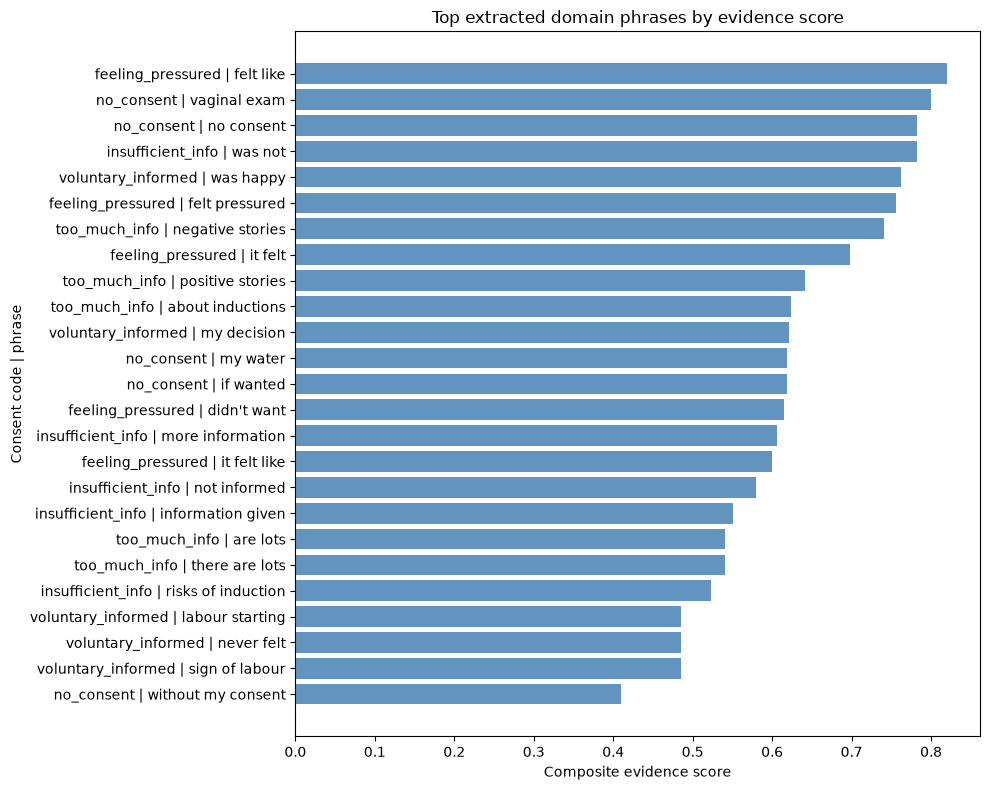

Top phrase candidates per consent code:

voluntary_informed
  was happy                           score=0.762 class_df=6
  my decision                         score=0.621 class_df=3
  labour starting                     score=0.485 class_df=2
  never felt                          score=0.485 class_df=2
  sign of labour                      score=0.485 class_df=2
  sign of labour starting             score=0.467 class_df=2
  go into labour naturally            score=0.467 class_df=2
  no sign of labour                   score=0.467 class_df=2

feeling_pressured
  felt like                           score=0.821 class_df=8
  felt pressured                      score=0.756 class_df=5
  it felt                             score=0.698 class_df=5
  didn't want                         score=0.615 class_df=5
  it felt like                        score=0.600 class_df=3
  want an induction                   score=0.534 class_df=3
  too much                            score=0.514 class_df=4
  say 

In [30]:
summary = (
    phrase_map
    .groupby('code_name')
    .agg(
        selected_phrases=('phrase', 'count'),
        median_class_doc_freq=('class_doc_freq', 'median'),
        max_evidence_score=('evidence_score', 'max'),
    )
    .reindex(CODE_NAMES)
    .reset_index()
)
display(summary)

# Show the strongest extracted phrases rather than a count that is fixed by design.
top_plot = (
    phrase_map
    .sort_values(['code_name', 'evidence_score'], ascending=[True, False])
    .groupby('code_name', group_keys=False)
    .head(5)
    .copy()
)
top_plot['phrase_label'] = top_plot['code_name'] + ' | ' + top_plot['phrase']
top_plot = top_plot.sort_values('evidence_score', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_plot['phrase_label'], top_plot['evidence_score'], color='steelblue', alpha=0.85)
ax.set_title('Top extracted domain phrases by evidence score')
ax.set_xlabel('Composite evidence score')
ax.set_ylabel('Consent code | phrase')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'domain_phrase_summary.png', dpi=160, bbox_inches='tight')
plt.show()

print('Top phrase candidates per consent code:')
for code_name in CODE_NAMES:
    subset = phrase_map[phrase_map['code_name'] == code_name].sort_values('evidence_score', ascending=False).head(8)
    print(f'\n{code_name}')
    for _, row in subset.iterrows():
        print(f"  {row['phrase']:35s} score={row['evidence_score']:.3f} class_df={int(row['class_doc_freq'])}")


## Next use

Load `data/domain_phrase_map.csv` and use it to create phrase-aware LIME text without changing the SetFit model input:

1. Replace selected phrases with underscore tokens before passing text to LIME, e.g. `no choice` → `no_choice`.
2. In the LIME prediction wrapper, convert underscores back to spaces before calling SetFit.
3. Display phrase tokens back as readable phrases.

This lets LIME perturb meaningful phrase units while the classifier still receives natural text.

In [ ]:
def encode_domain_phrases(text, phrase_table):
    encoded = canonical_text(text)
    # Longer phrases first prevents partial replacement inside longer phrases.
    phrase_col = 'canonical_phrase' if 'canonical_phrase' in phrase_table.columns else 'phrase'
    for phrase in sorted(phrase_table[phrase_col].dropna().unique(), key=lambda x: len(str(x).split()), reverse=True):
        token = str(phrase).replace(' ', '_')
        encoded = re.sub(r'(?<![a-z0-9])' + re.escape(str(phrase)) + r'(?![a-z0-9])', token, encoded, flags=re.IGNORECASE)
    return encoded


def decode_domain_phrases(text):
    return str(text).replace('_', ' ')

# Round-trip guardrail: selected phrases must survive canonicalization and encoding.
roundtrip_failures = []
for phrase in phrase_map['phrase'].dropna().head(60):
    sample = f'prefix {phrase} suffix'
    encoded = encode_domain_phrases(sample, phrase_map)
    decoded = decode_domain_phrases(encoded)
    if phrase not in decoded:
        roundtrip_failures.append((phrase, encoded, decoded))
if roundtrip_failures:
    raise AssertionError(f'Phrase round-trip failures: {roundtrip_failures[:5]}')

sample_text = dm_df.loc[5, 'response_text']
print('Original:')
print(sample_text)
print('\nPhrase-aware canonical version:')
print(encode_domain_phrases(sample_text, phrase_map))
print('\nRound-trip check passed for selected domain phrases.')


## Takeaways

- The phrase list is extracted from the actual decision-making responses using a reproducible scoring method.
- The exported phrase map should be treated as **candidate domain phrases** until reviewed against the snippets in `outputs/domain_phrase_audit.csv`.
- This supports phrase-aware LIME without randomly injecting hand-picked expressions.
- The model-performance claims still belong to Notebook 02; this notebook supports interpretability only.